In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Красивый стиль графиков
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Путь к датасету (ноутбук лежит в notebooks/, датасет — в data/)
DATA_PATH = os.path.join("..", "data", "credit_data.xls")

df = pd.read_excel(DATA_PATH, header=1)
df = df.rename(columns={"default payment next month": "target"})
df = df.drop(columns=["ID"])

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер датасета: (30000, 24)

Первые 5 строк:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
print("Пропуски по колонкам:")
print(df.isnull().sum())

print("\nТипы данных:")
print(df.dtypes.value_counts())

print("\nСтатистика по числовым признакам:")
df.describe().round(2)

Пропуски по колонкам:
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
target       0
dtype: int64

Типы данных:
int64    24
Name: count, dtype: int64

Статистика по числовым признакам:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,-0.27,...,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,1.13,...,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,-2.00,...,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,-1.00,...,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,0.00,...,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,0.00,...,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,8.00,...,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00


Распределение классов:
  Вернул (0): 23364 (77.9%)
  Дефолт (1): 6636 (22.1%)


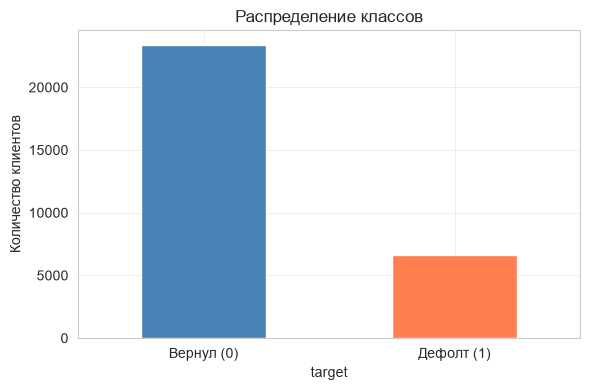

In [5]:
target_counts = df["target"].value_counts()
target_pct = df["target"].value_counts(normalize=True) * 100

print("Распределение классов:")
for val, cnt in target_counts.items():
    label = "Дефолт" if val == 1 else "Вернул"
    print(f"  {label} ({val}): {cnt} ({target_pct[val]:.1f}%)")

# График
fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind="bar", color=["steelblue", "coral"], ax=ax)
ax.set_title("Распределение классов")
ax.set_xticklabels(["Вернул (0)", "Дефолт (1)"], rotation=0)
ax.set_ylabel("Количество клиентов")
plt.tight_layout()
plt.savefig("class_balance.png", dpi=100)
plt.show()

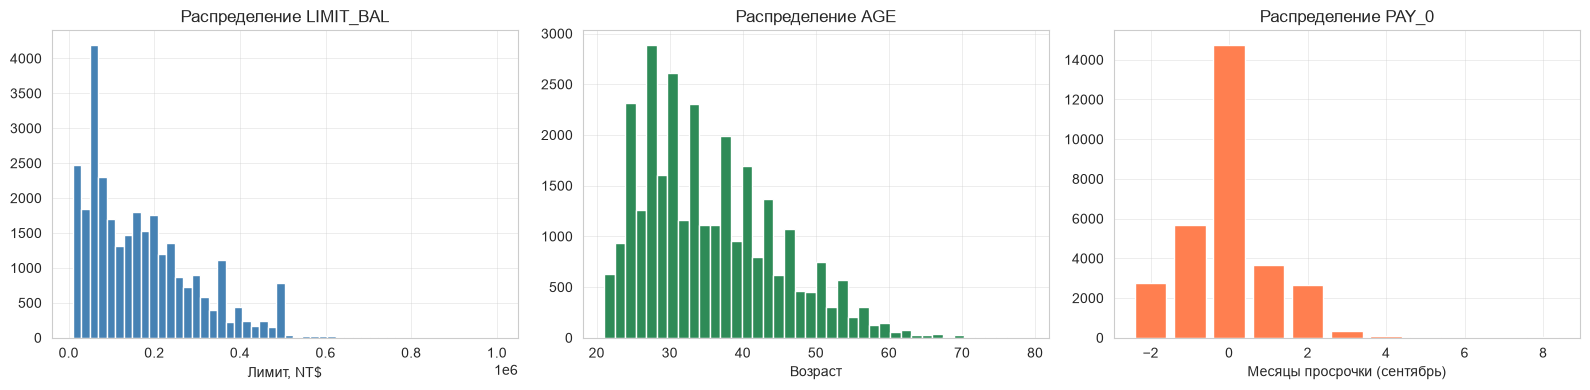

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Лимит по карте
axes[0].hist(df["LIMIT_BAL"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Распределение LIMIT_BAL")
axes[0].set_xlabel("Лимит, NT$")

# Возраст
axes[1].hist(df["AGE"], bins=40, color="seagreen", edgecolor="white")
axes[1].set_title("Распределение AGE")
axes[1].set_xlabel("Возраст")

# История просрочек PAY_0
pay_counts = df["PAY_0"].value_counts().sort_index()
axes[2].bar(pay_counts.index, pay_counts.values, color="coral", edgecolor="white")
axes[2].set_title("Распределение PAY_0")
axes[2].set_xlabel("Месяцы просрочки (сентябрь)")

plt.tight_layout()
plt.savefig("distributions.png", dpi=100)
plt.show()

=== Доля дефолтов по PAY_0 ===
       Доля дефолтов, %  Количество клиентов
PAY_0                                       
-2                 13.2                 2759
-1                 16.8                 5686
 0                 12.8                14737
 1                 33.9                 3688
 2                 69.1                 2667
 3                 75.8                  322
 4                 68.4                   76
 5                 50.0                   26
 6                 54.5                   11
 7                 77.8                    9
 8                 57.9                   19


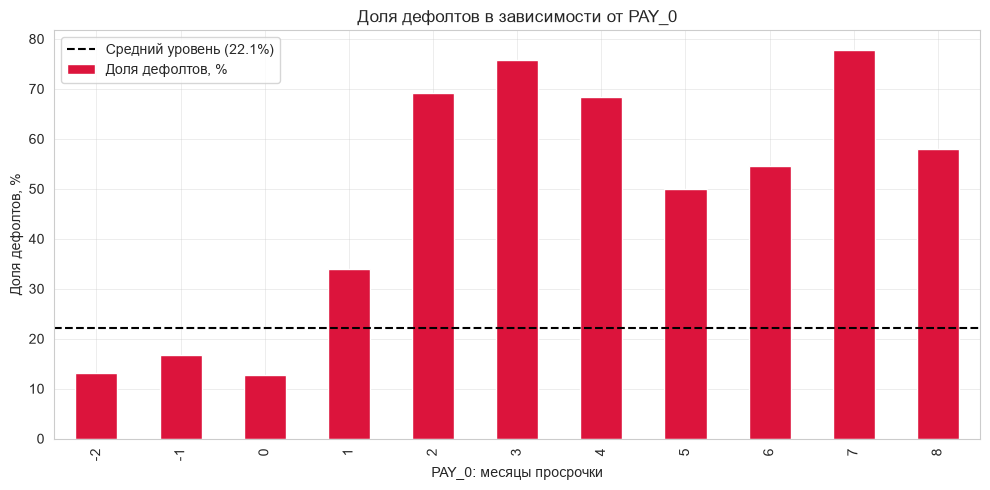

In [7]:
pay_stats = df.groupby("PAY_0")["target"].agg(["mean", "count"])
pay_stats["mean"] = (pay_stats["mean"] * 100).round(1)
pay_stats.columns = ["Доля дефолтов, %", "Количество клиентов"]

print("=== Доля дефолтов по PAY_0 ===")
print(pay_stats)

# График
fig, ax = plt.subplots(figsize=(10, 5))
pay_stats["Доля дефолтов, %"].plot(kind="bar", color="crimson", edgecolor="white", ax=ax)
ax.set_title("Доля дефолтов в зависимости от PAY_0")
ax.set_xlabel("PAY_0: месяцы просрочки")
ax.set_ylabel("Доля дефолтов, %")
ax.axhline(y=df["target"].mean() * 100, color="black", linestyle="--",
           label=f"Средний уровень ({df['target'].mean()*100:.1f}%)")
ax.legend()
plt.tight_layout()
plt.savefig("pay0_default_rate.png", dpi=100)
plt.show()

=== Доля дефолтов по EDUCATION ===
             Доля дефолтов, %  Количество клиентов
0                         0.0                   14
Аспирантура              19.2                10585
Университет              23.7                14030
Школа                    25.2                 4917
Другое                    5.7                  123
5                         6.4                  280
6                        15.7                   51


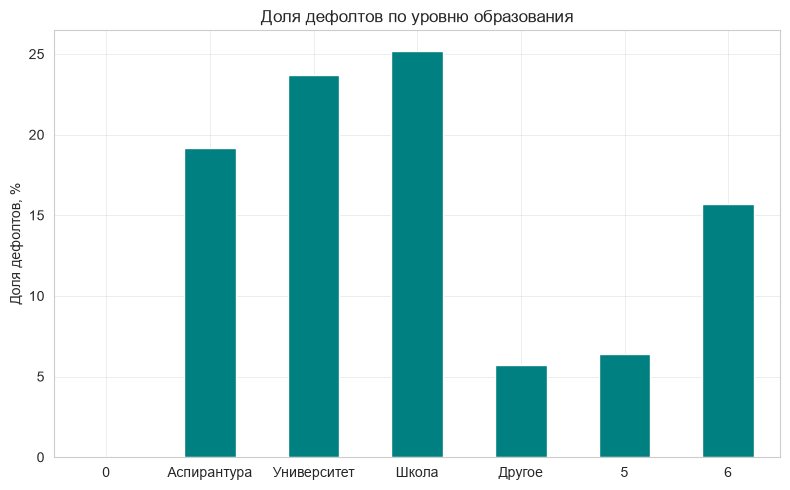

In [8]:
edu_stats = df.groupby("EDUCATION")["target"].agg(["mean", "count"])
edu_stats["mean"] = (edu_stats["mean"] * 100).round(1)
edu_stats.columns = ["Доля дефолтов, %", "Количество клиентов"]

edu_labels = {1: "Аспирантура", 2: "Университет", 3: "Школа", 4: "Другое"}
edu_stats.index = [edu_labels.get(i, i) for i in edu_stats.index]

print("=== Доля дефолтов по EDUCATION ===")
print(edu_stats)

fig, ax = plt.subplots(figsize=(8, 5))
edu_stats["Доля дефолтов, %"].plot(kind="bar", color="teal", edgecolor="white", ax=ax)
ax.set_title("Доля дефолтов по уровню образования")
ax.set_ylabel("Доля дефолтов, %")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("education_default_rate.png", dpi=100)
plt.show()

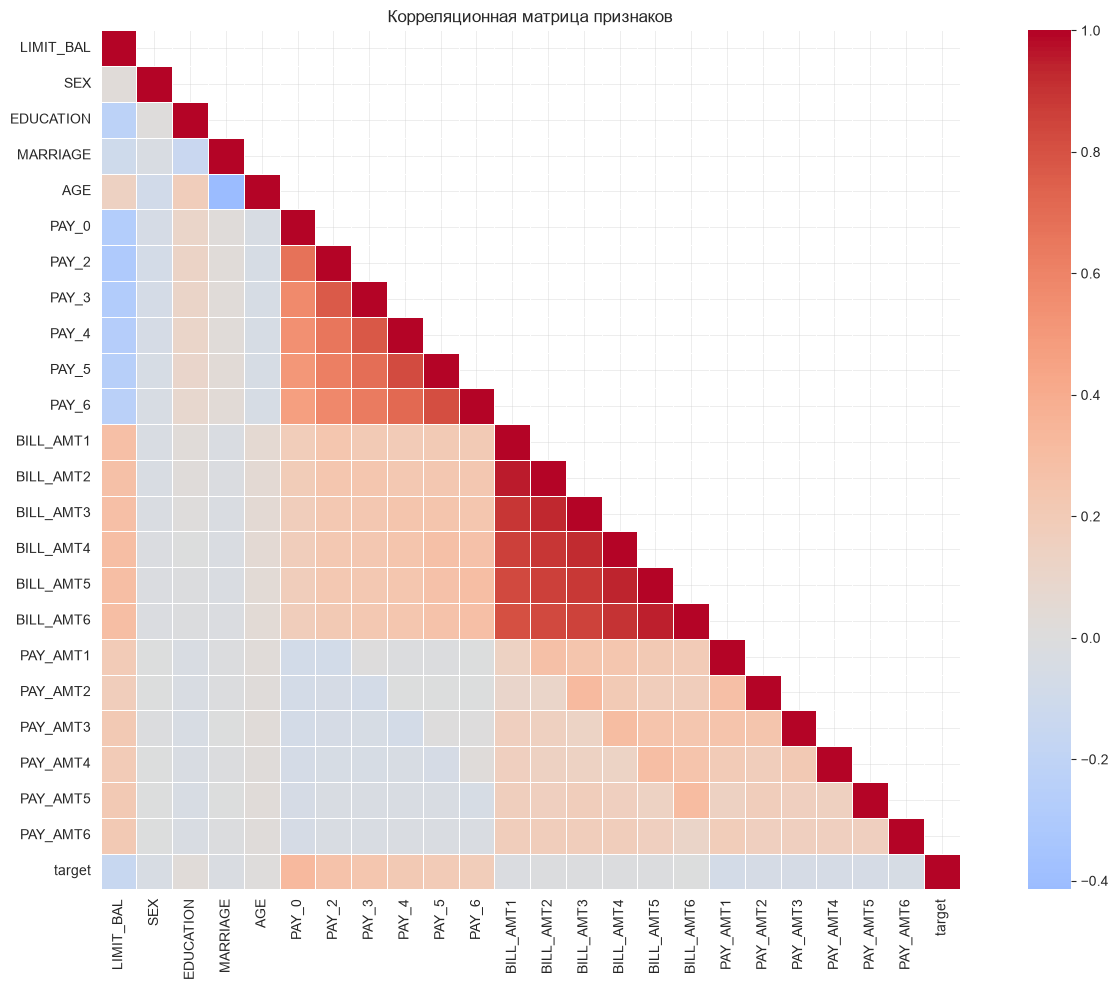

Корреляция признаков с target:
PAY_0        0.325
PAY_2        0.264
PAY_3        0.235
PAY_4        0.217
PAY_5        0.204
PAY_6        0.187
EDUCATION    0.028
AGE          0.014
BILL_AMT6   -0.005
BILL_AMT5   -0.007
BILL_AMT4   -0.010
BILL_AMT3   -0.014
BILL_AMT2   -0.014
BILL_AMT1   -0.020
MARRIAGE    -0.024
SEX         -0.040
PAY_AMT6    -0.053
PAY_AMT5    -0.055
PAY_AMT3    -0.056
PAY_AMT4    -0.057
PAY_AMT2    -0.059
PAY_AMT1    -0.073
LIMIT_BAL   -0.154
Name: target, dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(14, 10))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            annot=False, square=True, linewidths=0.5, ax=ax)
ax.set_title("Корреляционная матрица признаков")
plt.tight_layout()
plt.savefig("correlation.png", dpi=100)
plt.show()

# Корреляции с target
target_corr = corr["target"].drop("target").sort_values(ascending=False)
print("Корреляция признаков с target:")
print(target_corr.round(3))

In [10]:
print("""
=== ВЫВОДЫ РАЗВЕДОЧНОГО АНАЛИЗА ===

1. Дисбаланс классов: дефолты составляют ~22% выборки.
   → Accuracy обманчива, нужны recall, F1, ROC-AUC.

2. Пропусков нет, все признаки числовые.
   → Кодирование категориальных признаков не требуется.

3. Сильнейший признак — PAY_0 (история просрочек).
   Клиенты без задолженности (PAY_0 = -2): ~14% дефолтов.
   Клиенты с просрочкой 2 месяца (PAY_0 = 2): ~69% дефолтов.
   → Разница в 5 раз. Модель должна опираться именно на эти признаки.

4. Слабые признаки — EDUCATION, SEX, MARRIAGE.
   Разница в доле дефолтов между уровнями образования — 5–7%.
   → Модель почти не реагирует на изменение этих признаков.
   Это также означает, что их можно исключить из модели
   без потери качества (и это соответствует регуляторным нормам —
   запрет на дискриминацию по полу и семейному положению).

5. Признаки BILL_AMT и PAY_AMT информативны, но слабее PAY_*.
""")


=== ВЫВОДЫ РАЗВЕДОЧНОГО АНАЛИЗА ===

1. Дисбаланс классов: дефолты составляют ~22% выборки.
   → Accuracy обманчива, нужны recall, F1, ROC-AUC.

2. Пропусков нет, все признаки числовые.
   → Кодирование категориальных признаков не требуется.

3. Сильнейший признак — PAY_0 (история просрочек).
   Клиенты без задолженности (PAY_0 = -2): ~14% дефолтов.
   Клиенты с просрочкой 2 месяца (PAY_0 = 2): ~69% дефолтов.
   → Разница в 5 раз. Модель должна опираться именно на эти признаки.

4. Слабые признаки — EDUCATION, SEX, MARRIAGE.
   Разница в доле дефолтов между уровнями образования — 5–7%.
   → Модель почти не реагирует на изменение этих признаков.
   Это также означает, что их можно исключить из модели
   без потери качества (и это соответствует регуляторным нормам —
   запрет на дискриминацию по полу и семейному положению).

5. Признаки BILL_AMT и PAY_AMT информативны, но слабее PAY_*.

